In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('ggplot')
sns.set


<function seaborn.rcmod.set(*args, **kwargs)>

In [2]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [4]:
df = pd.DataFrame(housing['data'], columns=housing['feature_names'])
df['median_house_value'] = housing['target']


In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
print(df.shape)
print(df.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  median_house_value  
0    -122.23               4.526  
1    -122.22               3.585  
2    -122.24               3.521  
3    -122.25               3.413  
4    -122.25               3.422  


In [7]:
df.describe(include='number')

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
cols = df.columns
print(cols)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'median_house_value'],
      dtype='object')


In [9]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
median_house_value,0


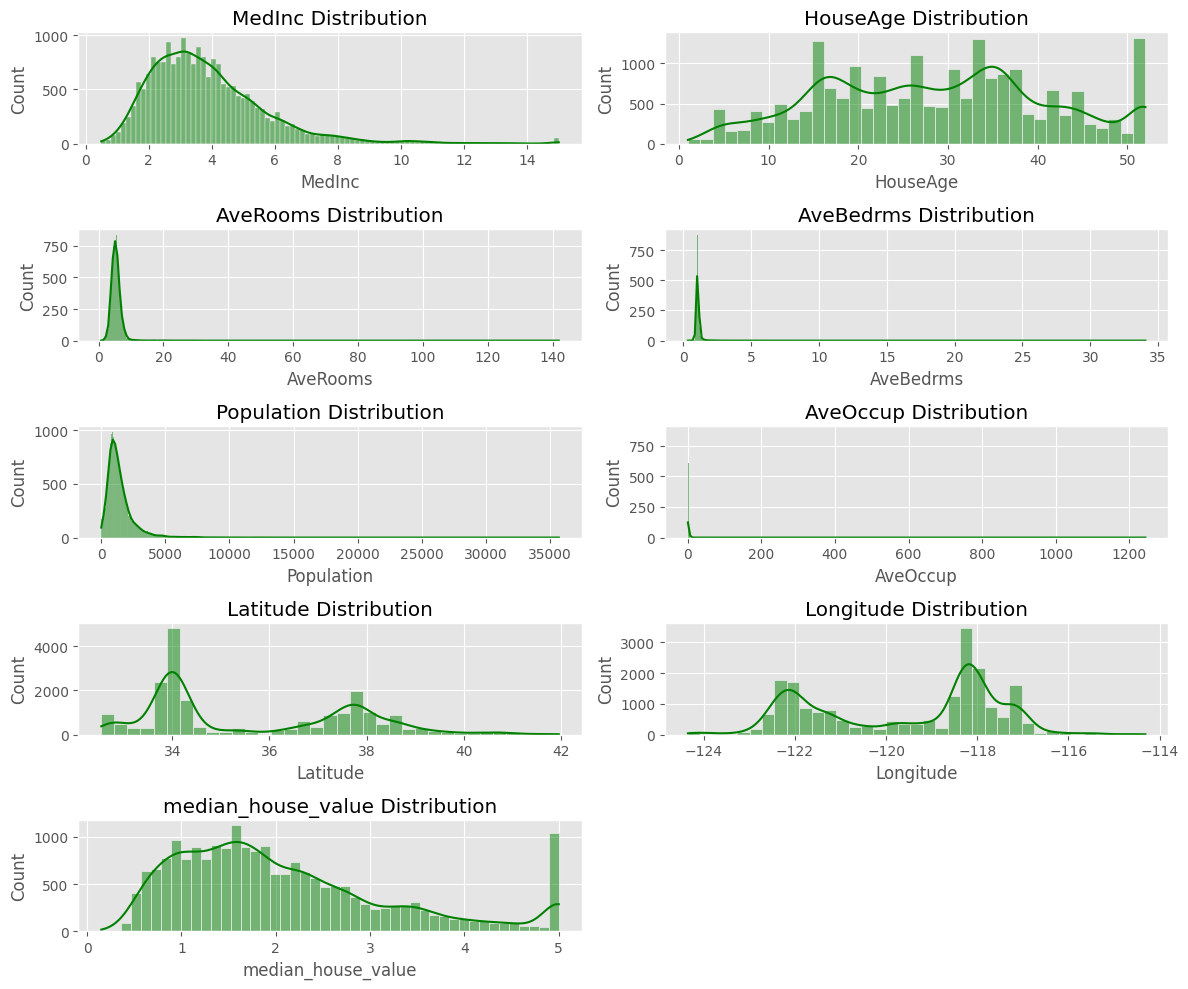

In [10]:
# Check the Distribution of Variables - (Histplot)
import math
num_cols = len(cols)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)
plt.figure(figsize=(12,grid_cols*5))
for index, i in enumerate(cols):
  plt.subplot(grid_rows, grid_cols, index+1)
  sns.histplot(x=i, data=df,color='green', kde=True)
  plt.xlabel(i, fontsize=12)
  plt.title(f"{i} Distribution")
plt.tight_layout()
plt.show()

We can see in aboove figure that there is skewness in features data distribution. So let's check for **outliers through Boxplot** in features :-

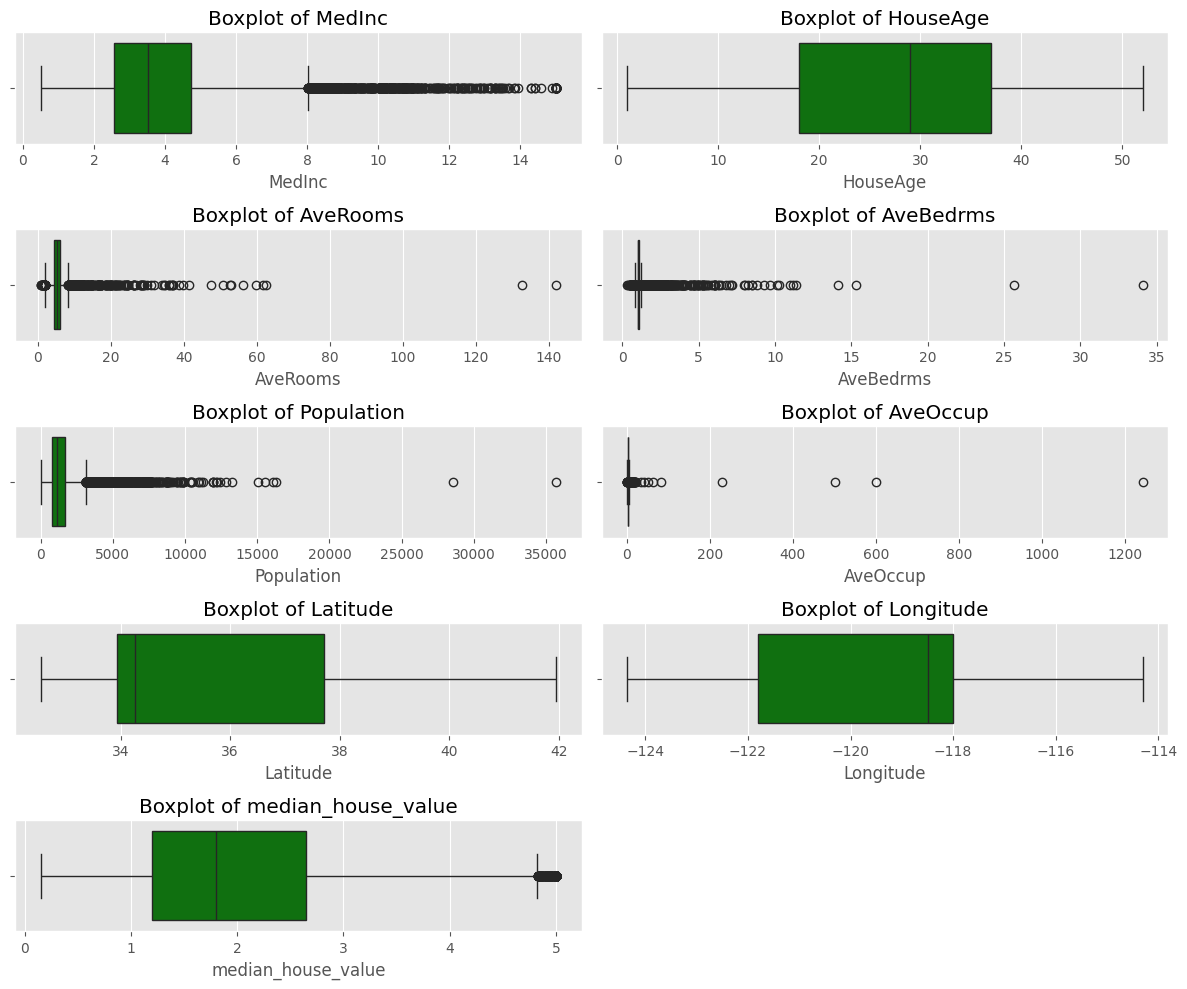

In [11]:
num_cols = len(cols)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)
plt.figure(figsize= (12,grid_cols*5))
for index, i in enumerate(cols):
  plt.subplot(grid_rows,grid_cols, index+1)
  sns.boxplot(x=i, data=df, color='green')
  plt.xlabel(i)
  plt.title(f"Boxplot of {i}")
plt.tight_layout()
plt.show()

As we see that some features have outliers so let's draw a **Heatmap** and see how much these features are correlated with target variable :-

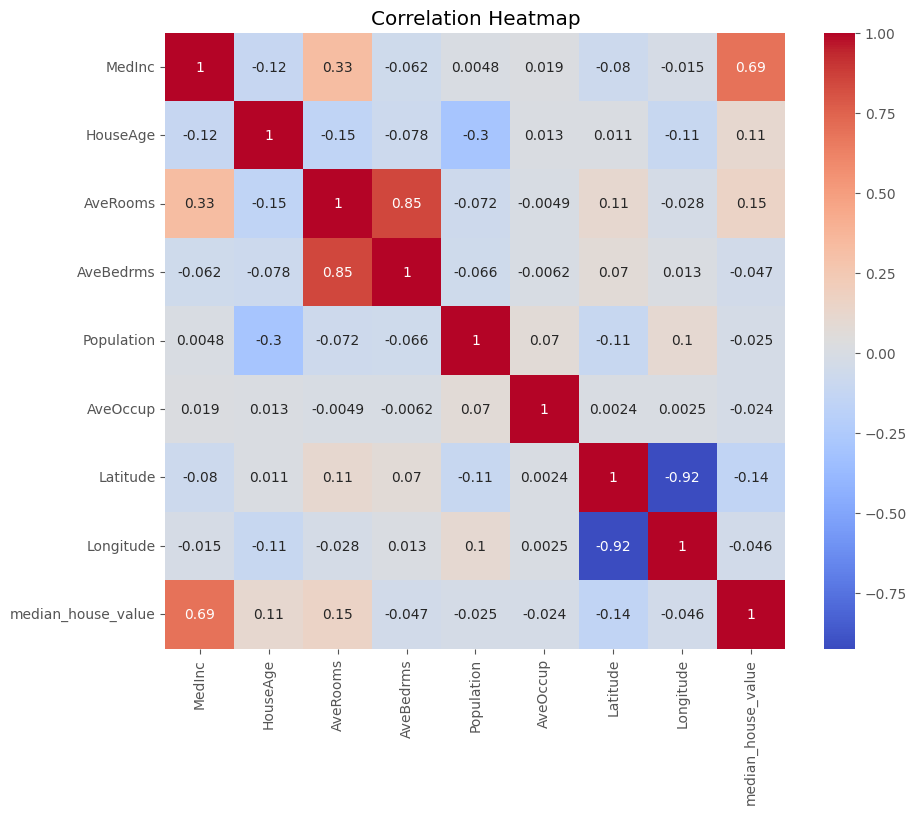

In [12]:
# Heatmap
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

* As we see in **heatmap** some features are showing **negative correlation** with target variable but we can't drop them so earlier.
* So let's draw **Scatter plot** and check that how much these features are correlated with target variable (median_house_value).

In [13]:
cols2 = ['AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']

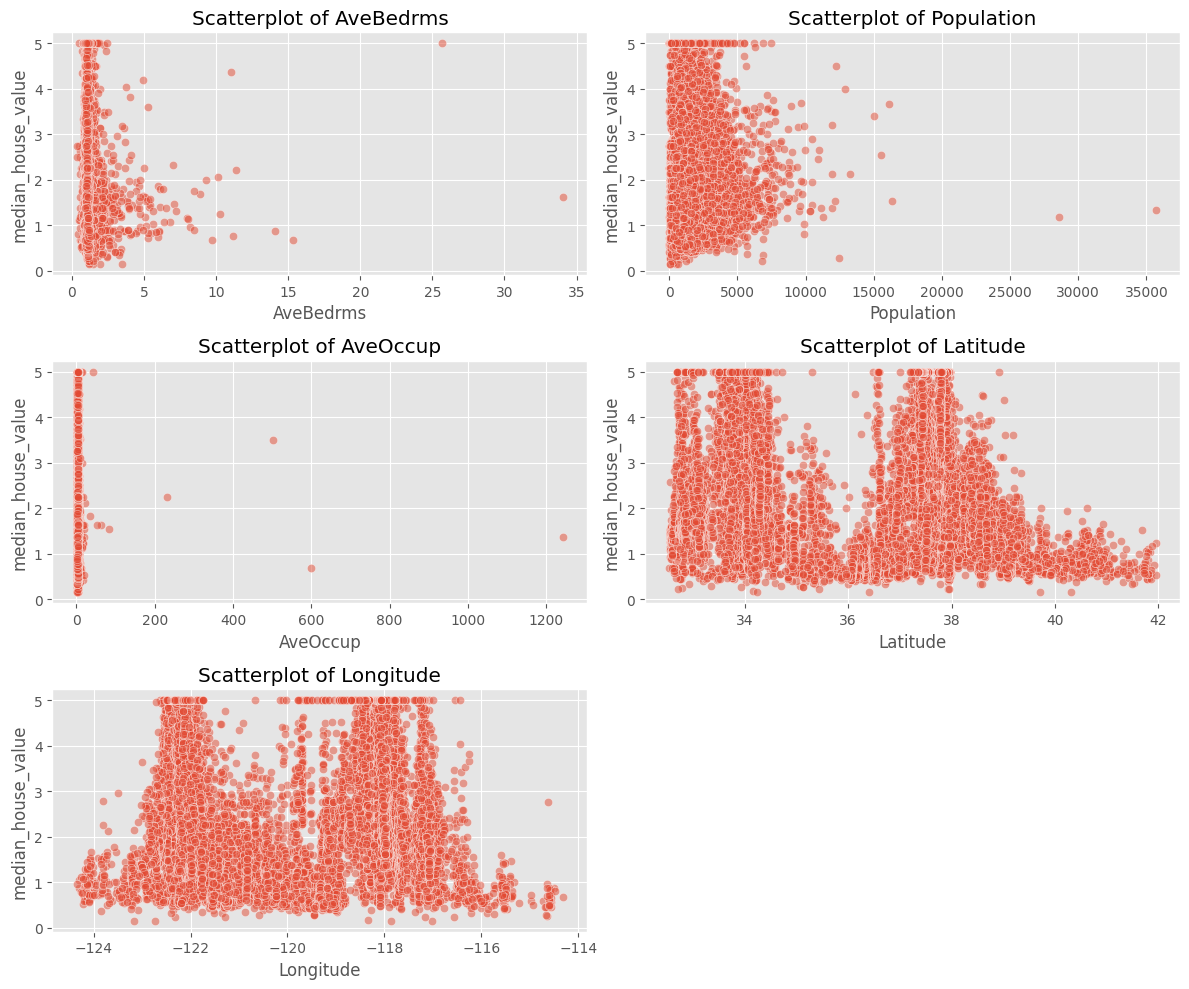

In [14]:
# Scatter plot for cols2 features
import math
num_cols = len(cols2)
grid_cols = 2
grid_rows = math.ceil(num_cols/grid_cols)
plt.figure(figsize=(12,grid_cols*5))
for index, i in enumerate(cols2):
  plt.subplot(grid_rows, grid_cols, index+1)
  sns.scatterplot(data=df, x=i,y='median_house_value',alpha=0.5, palette='viridis')
  plt.xlabel(i)
  plt.title(f"Scatterplot of {i}")
plt.tight_layout()
plt.show()

* As we see that ['AveBedrms', 'Population', 'AveOccup'] have not a good relation with target feature.
* But we know that **['Latitude', 'Longitude']** are the import features for predicting the house value, So let's draw scatter plot and see the relation between them.

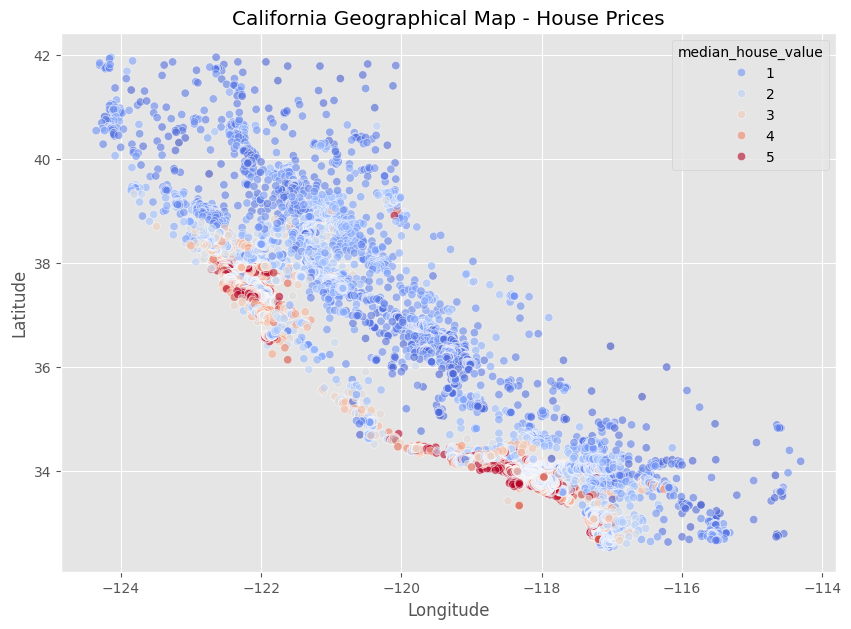

In [15]:
# Scatter plot between 'Longitude' and 'Latitude'

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Longitude', y='Latitude', hue='median_house_value', palette='coolwarm', alpha=0.6, data=df)
plt.title('California Geographical Map - House Prices')
plt.show()


* Above Scatterplot is showing that 'longitude' & 'Latitude' are strongly correlated and say that the House Price is higher near sea.
* Though these are in Non-Linear relation with target variable still these are important features so we can't drop them.

In [16]:
df2 = df.drop(['AveBedrms', 'Population', 'AveOccup'], axis=1)

In [17]:
x = df2.drop('median_house_value', axis=1)
y = df2['median_house_value']

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

* As we know that 2 features ['longitude', 'Latitude'] are in Non-Linear relationship with target feature, In that case Distance Based algorithms (models) wouldn't work so good.

In [19]:
# Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [20]:
model.score(x_train, y_train)

0.5984528848684194

In [21]:
model.score(x_test, y_test)

0.5813744243302476

Though Non Linear relation's features are also incude so Linear regression score isn't so good.

In [22]:
# KNN
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=25)
model.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=25)

In [23]:
model.score(x_train, y_train)

0.6742401903191548

In [24]:
model.score(x_test, y_test)

0.6353254908561972

In [25]:
# SVR
from sklearn.svm import SVR
model = SVR(kernel='rbf')
model.fit(x_train, y_train)

SVR()

In [26]:
model.score(x_train, y_train)

0.5505743881270386

In [27]:
model.score(x_test, y_test)

0.5313564417270358

In [28]:
# DecisionTreeRegressor
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(criterion='absolute_error', max_depth=6, min_samples_split=10,min_samples_leaf=5)
model.fit(x_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=6,
                      min_samples_leaf=5, min_samples_split=10)

In [29]:
model.score(x_train, y_train)

0.6361869794540131

In [30]:
model.score(x_test, y_test)

0.5987602403444703

In [31]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, criterion='absolute_error', max_depth=7)
model.fit(x_train, y_train)

RandomForestRegressor(criterion='absolute_error', max_depth=7)

In [32]:
model.score(x_train, y_train)

0.7228648459013758

In [33]:
model.score(x_test,y_test)

0.6792726265637493

In [34]:
# AdaBoostRegressor
from sklearn.ensemble import AdaBoostRegressor
model = AdaBoostRegressor(n_estimators=50, learning_rate=0.1)
model.fit(x_train, y_train)

AdaBoostRegressor(learning_rate=0.1)

In [35]:
model.score(x_train, y_train)

0.5515272309288575

In [36]:
model.score(x_test, y_test)

0.5312615410200567

In [37]:
# XGBRegressor
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4)
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [38]:
model.score(x_train, y_train)

0.8075320348067985

In [39]:
model.score(x_test, y_test)

0.7785611417881678

In [40]:
# GradientBoostingRegressor
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4)
model.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=4)

In [41]:
model.score(x_train, y_train)

0.8080360581714058

In [42]:
model.score(x_test, y_test)

0.7727184633675569

In [43]:
# ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesRegressor
model = ExtraTreesRegressor(n_estimators=100, criterion='absolute_error', max_depth=8)
model.fit(x_train, y_train)

ExtraTreesRegressor(criterion='absolute_error', max_depth=8)

In [44]:
model.score(x_train, y_train)

0.6203506176653348

In [45]:
model.score(x_test, y_test)

0.5823118005076249

In [46]:
# BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
model = BaggingRegressor(n_estimators=100, max_samples=500, random_state=42)
model.fit(x_train, y_train)

BaggingRegressor(max_samples=500, n_estimators=100, random_state=42)

In [47]:
model.score(x_train, y_train)

0.7186029846914928

In [48]:
model.score(x_test,y_test)

0.6827649914910783

In [49]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [50]:
# CatBoostRegressor
from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=100,      # Number of Trees (n_estimators)
    learning_rate=0.1,   # Learning Speed
    depth=6, # depth of tree
    verbose = False              #  Iterations wouldn't be shown in o/p.
)
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=100, learning_rate=0.1, loss_function='RMSE', verbose=False)

In [51]:
model.score(x_train, y_train)

np.float64(0.7900709689475257)

In [52]:
model.score(x_test, y_test)

np.float64(0.7678265392684871)

In [53]:
# HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
model = HistGradientBoostingRegressor(max_iter=100, max_depth=3, learning_rate=0.1)
model.fit(x_train, y_train)

HistGradientBoostingRegressor(max_depth=3)

In [54]:
model.score(x_train, y_train)

0.7735186101571212

In [55]:
model.score(x_test, y_test)

0.7504073020605565

# To select the Best Model, getting mae and R2 Score through Pipeline.

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,  mean_absolute_percentage_error

# Base pipeline banaya
base_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', None)      # Model, None ki jagah kuch b likh sake, same ise format me
    ])

# Different models import karna (All these imported above, just for reminder)
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import BaggingRegressor
from catboost import CatBoostRegressor

# 2. Models ki Dictionary Banana
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, criterion='absolute_error', max_depth=7),
    'grad_boost' : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4),
    'xgb' : XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=4),
    'bagging' : BaggingRegressor(n_estimators=100, max_samples=500,random_state=42),
    'catboost' : CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose = False)

}

# 3. Loop chala kar har model ka MAE, R2 score nikalna
mae_results = {}
mse_results = {}
r2_results = {}
mape_results = {}                             # mean absolute percentage_error
for model_name, model in models.items():
  base_pipeline.set_params(model=model)
  base_pipeline.fit(x_train, y_train)
  y_pred = base_pipeline.predict(x_test)

  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mape = mean_absolute_percentage_error(y_test, y_pred)

  mae_results[model_name] = mae
  r2_results[model_name] = r2
  mse_results[model_name] = mse
  mape_results[model_name] = mape

Finding the MAE, MSE & R2 Score score

In [57]:
error_list = [mae_results, mse_results, r2_results]
metric_names = ["MAE", "MSE", "R2 Score"]       # Unke sahi naam ek alag list mein rakh liye (Y-axis aur Title ke liye)

for index, error in enumerate(error_list):
  curr_metric = metric_names[index]
  if curr_metric == "R2 Score":
    best_model_name = max(error, key=error.get)
    condition_text = "highest"
  else:
    best_model_name = min(error, key=error.get)
    condition_text = "lowest"

  print(f"--- {curr_metric} Evaluation Results ---")

  for model_name, val in error.items():                                 # print the model's name and related value
    print(f"{model_name} {curr_metric.lower()}: {val:.4f}")
  best_val = error[best_model_name]                                     # Get the best model value dyanamically by 'error[best_model_name]'
  print(f"Best Model Selected: {best_model_name} (with {condition_text} {curr_metric}: {best_val:.4f}))\n")


--- MAE Evaluation Results ---
Random Forest mae: 0.4188
grad_boost mae: 0.3750
xgb mae: 0.3696
bagging mae: 0.4530
catboost mae: 0.3784
Best Model Selected: xgb (with lowest MAE: 0.3696))

--- MSE Evaluation Results ---
Random Forest mse: 0.4191
grad_boost mse: 0.2981
xgb mse: 0.2902
bagging mse: 0.4156
catboost mse: 0.3042
Best Model Selected: xgb (with lowest MSE: 0.2902))

--- R2 Score Evaluation Results ---
Random Forest r2 score: 0.6802
grad_boost r2 score: 0.7725
xgb r2 score: 0.7786
bagging r2 score: 0.6828
catboost r2 score: 0.7678
Best Model Selected: xgb (with highest R2 Score: 0.7786))



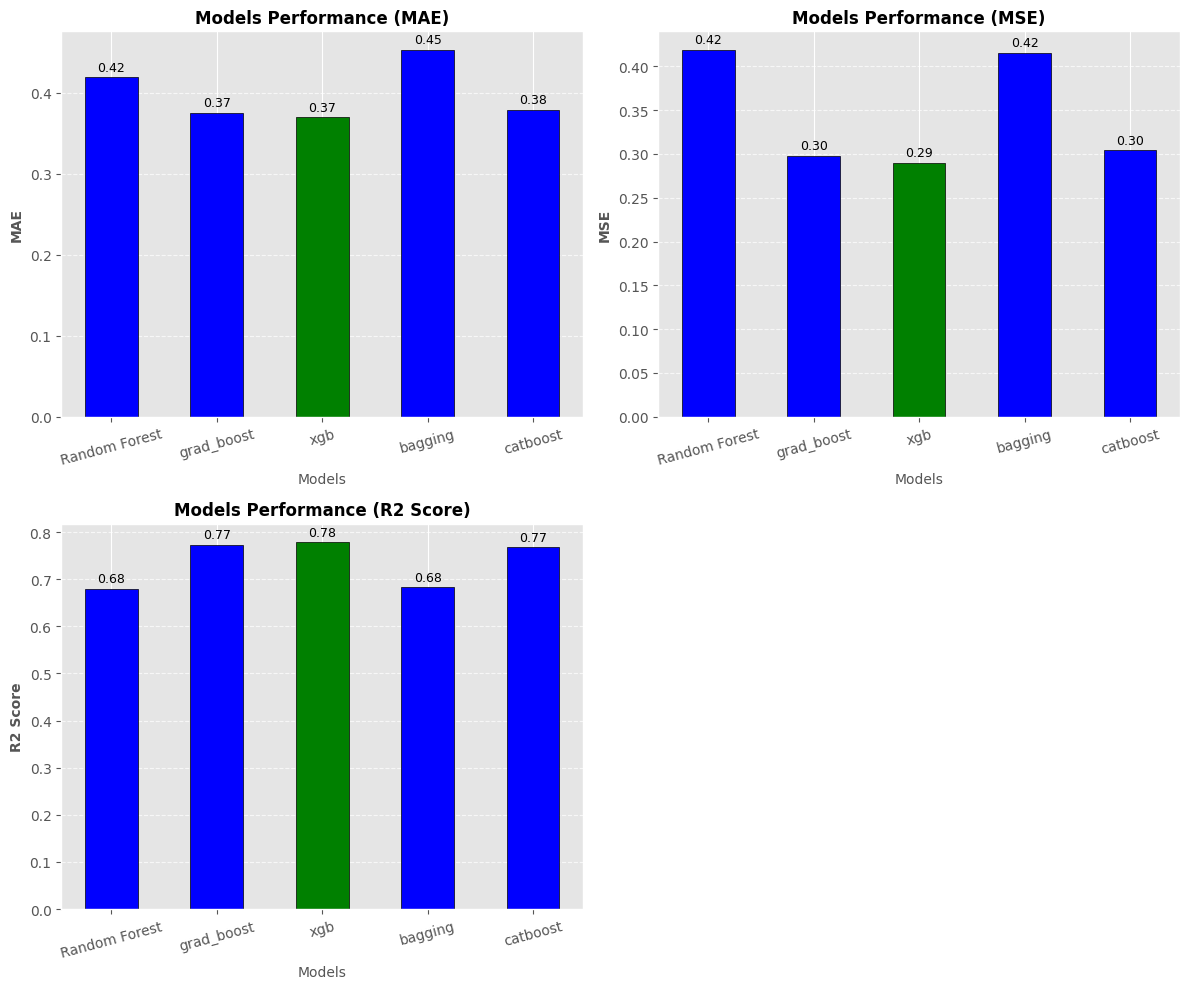

In [58]:
 # Plot All models' performance through barplot
error_list = [mae_results, mse_results, r2_results]
metric_names = ["MAE", "MSE", "R2 Score"]       # Unke sahi naam ek alag list mein rakh liye (Y-axis aur Title ke liye)
grid_rows = 2
grid_cols = 2

plt.figure(figsize=(12, 10))
for index, error in enumerate(error_list):
  current_metric = metric_names[index]
  plt.subplot(grid_rows, grid_cols, index + 1)
  if current_metric == "R2 Score":
    best_model_name = max(error, key=error.get)
  else:
    best_model_name = min(error, key=error.get)
  colors = ['green' if model == best_model_name else 'blue' for model in error.keys()]  # Best Model 'Green' baki sab 'Blue' color me show honge.
  bars = plt.bar(error.keys(), error.values(), color=colors, edgecolor='black', width=0.5)

    # Bars ke upar text values dikhane ke liye
  for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(error.values())*0.01), f"{yval:.2f}", ha='center', va='bottom', fontsize=9)

    # Label aur Titles ko metric_names list se dynamic uthaya
  # current_metric = metric_names[index]
  plt.title(f"Models Performance ({current_metric})", fontsize=12, fontweight='bold')
  plt.xlabel('Models', fontsize=10)
  plt.ylabel(current_metric, fontsize=10, fontweight='bold')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.xticks(rotation=15)                          # Model ke naam aapas mein takrayein na, isliye thoda ghuma diya
plt.tight_layout()
plt.show()


# Cross Validation on Best Model (XGBoost)

In [59]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)       # Suffle data with kfold so that data could be mix in each fold.
xgb_model = XGBRegressor(iterations=100, learning_rate=0.1, max_depth=4)
score = cross_val_score(xgb_model, x_train, y_train, cv=kf)

print(f"The xgb_model's score is: {score}")
print(f"The mean of scores is: {score.mean()}")


The xgb_model's score is: [0.78191768 0.78989161 0.79276981 0.77307307 0.78220266]
The mean of scores is: 0.7839709656544548


In [60]:
xgb_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None, iterations=100,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, ...)

In [61]:
xgb_model.score(x_train, y_train)

0.8075320348067985

In [62]:
xgb_model.score(x_test, y_test)

0.7785611417881678

In [63]:
y_pred = xgb_model.predict(x_test)

In [64]:
# y_test

# **Model Evaluation**

In [65]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nTop 5 Comparisons:")                                   # For Seeing top 5 records
print(comparison_df.head())


Top 5 Comparisons:
        Actual  Predicted
20046  0.47700   0.584888
3024   0.45800   0.925145
15663  5.00001   4.379020
20484  2.18600   2.668931
9814   2.78000   2.361295


# As We see that **XGBRegressor** performing highest R2 score, lowest errors, good cross validation score & Predictions so we consider it best fit model for california_housing.